In [10]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install --upgrade matplotlib numpy pandas seaborn

  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install ydata-profiling

  Using cached pandas-2.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 7.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.1 MB/s eta 0:00:00
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 15.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 17.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 14.6 MB/s eta 0:00:0000:0100:01
Using cached pandas-2.3.3-cp311-cp311-macosx_11_0_arm64.whl (10.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.5/665.5 kB 15.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.6/175.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9

In [21]:
conda update numpy matplotlib pandas seaborn

Retrieving notices: ...working... done

PackageNotInstalledError: Package is not installed in prefix.
  prefix: /opt/anaconda3
  package name: pandas



Note: you may need to restart the kernel to use updated packages.


In [1]:
# Essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For profiling
from ydata_profiling import ProfileReport

Importing Dataset

In [ ]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
census_income_kdd = fetch_ucirepo(id=117) 
  
# data (as pandas dataframes) 
X = census_income_kdd.data.features 
y = census_income_kdd.data.targets 

print("Dataset loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

✓ Dataset loaded successfully!
Features shape: (199523, 41)
Target shape: (199523, 1)


In [ ]:
# This combines features (X) and target (y) into one dataframe
data = X.copy()
data['income'] = y

print("✓ Combined dataframe created!")
print(f"Total shape: {data.shape}")
print(f"Columns: {data.shape[1]}")

✓ Combined dataframe created!
Total shape: (199523, 42)
Columns: 42


In [9]:
# metadata 
print(census_income_kdd.metadata) 
  
# variable information 
print(census_income_kdd.variables) 

{'uci_id': 117, 'name': 'Census-Income (KDD)', 'repository_url': 'https://archive.ics.uci.edu/dataset/117/census+income+kdd', 'data_url': 'https://archive.ics.uci.edu/static/public/117/data.csv', 'abstract': 'This data set contains weighted census data extracted from the 1994 and 1995 current population surveys conducted by the U.S. Census Bureau.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 299285, 'num_features': 41, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Education Level', 'Marital Status', 'Race', 'Sex', 'Other', 'Nationality', 'Income'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5N30T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set contains weighted census data extracted from the 

Basic Inspection of Dataset

In [ ]:
# First 5 rows
print("="*50)
print("FIRST 5 ROWS")
print("="*50)
data.head(5)

FIRST 5 ROWS


,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,ARACE,...,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,AHRSPAY,year,income
0,73,Not in universe,0,0,High school graduate,Not in universe,Widowed,Not in universe or children,Not in universe,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,Not in universe,Divorced,Construction,Precision production craft & repair,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
2,18,Not in universe,0,0,10th grade,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,...,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,0,95,-50000
3,9,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
4,10,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000


In [ ]:
# Column names and data types
print("="*50)
print("COLUMN INFORMATION")
print("="*50)
data.info()

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AAGE       199523 non-null  int64  
 1   ACLSWKR    199523 non-null  object 
 2   ADTINK     199523 non-null  int64  
 3   ADTOCC     199523 non-null  int64  
 4   AHGA       199523 non-null  object 
 5   AHSCOL     199523 non-null  object 
 6   AMARITL    199523 non-null  object 
 7   AMJIND     199523 non-null  object 
 8   AMJOCC     199523 non-null  object 
 9   ARACE      199523 non-null  object 
 10  AREORGN    199523 non-null  object 
 11  ASEX       199523 non-null  object 
 12  AUNMEM     199523 non-null  object 
 13  AUNTYPE    199523 non-null  object 
 14  AWKSTAT    199523 non-null  object 
 15  CAPGAIN    199523 non-null  int64  
 16  GAPLOSS    199523 non-null  int64  
 17  DIVVAL     199523 non-null  int64  
 18  FILESTAT   199523 non-null  object 
 19  GRIN

In [ ]:
# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove 'income' from lists if present (it's our target)
if 'income' in numerical_cols:
    numerical_cols.remove('income')
if 'income' in categorical_cols:
    categorical_cols.remove('income')

print("="*50)
print("VARIABLE TYPES")
print("="*50)
print(f"\nNumerical columns ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  • {col}")

print(f"\nCategorical columns ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  • {col}")

print(f"\nTarget variable: income")

VARIABLE TYPES

Numerical columns (13):
  • AAGE
  • ADTINK
  • ADTOCC
  • CAPGAIN
  • GAPLOSS
  • DIVVAL
  • MARSUPWRT
  • NOEMP
  • SEOTR
  • VETYN
  • WKSWORK
  • AHRSPAY
  • year

Categorical columns (28):
  • ACLSWKR
  • AHGA
  • AHSCOL
  • AMARITL
  • AMJIND
  • AMJOCC
  • ARACE
  • AREORGN
  • ASEX
  • AUNMEM
  • AUNTYPE
  • AWKSTAT
  • FILESTAT
  • GRINREG
  • GRINST
  • HHDFMX
  • HHDREL
  • MIGMTR1
  • MIGMTR3
  • MIGMTR4
  • MIGSAME
  • MIGSUN
  • PARENT
  • PEFNTVTY
  • PEMNTVTY
  • PENATVTY
  • PRCITSHP
  • VETQVA

Target variable: income


Data Quality Check

In [ ]:
# Missing values analysis
print("="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)

missing_counts = data.isnull().sum()
missing_percentages = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.values
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found!")

MISSING VALUES ANALYSIS
  Column  Missing_Count  Missing_Percentage
 MIGMTR1          99696           49.967172
 MIGMTR3          99696           49.967172
 MIGMTR4          99696           49.967172
  MIGSUN          99696           49.967172
PEFNTVTY           6713            3.364524
PEMNTVTY           6119            3.066814
PENATVTY           3393            1.700556
  GRINST            708            0.354846


In [ ]:
# Check for duplicates
duplicates = data.duplicated().sum()
print("="*50)
print("DUPLICATE ROWS")
print("="*50)
print(f"Number of duplicate rows: {duplicates:,}")
print(f"Percentage: {(duplicates/len(data)*100):.2f}%")

DUPLICATE ROWS
Number of duplicate rows: 3,229
Percentage: 1.62%


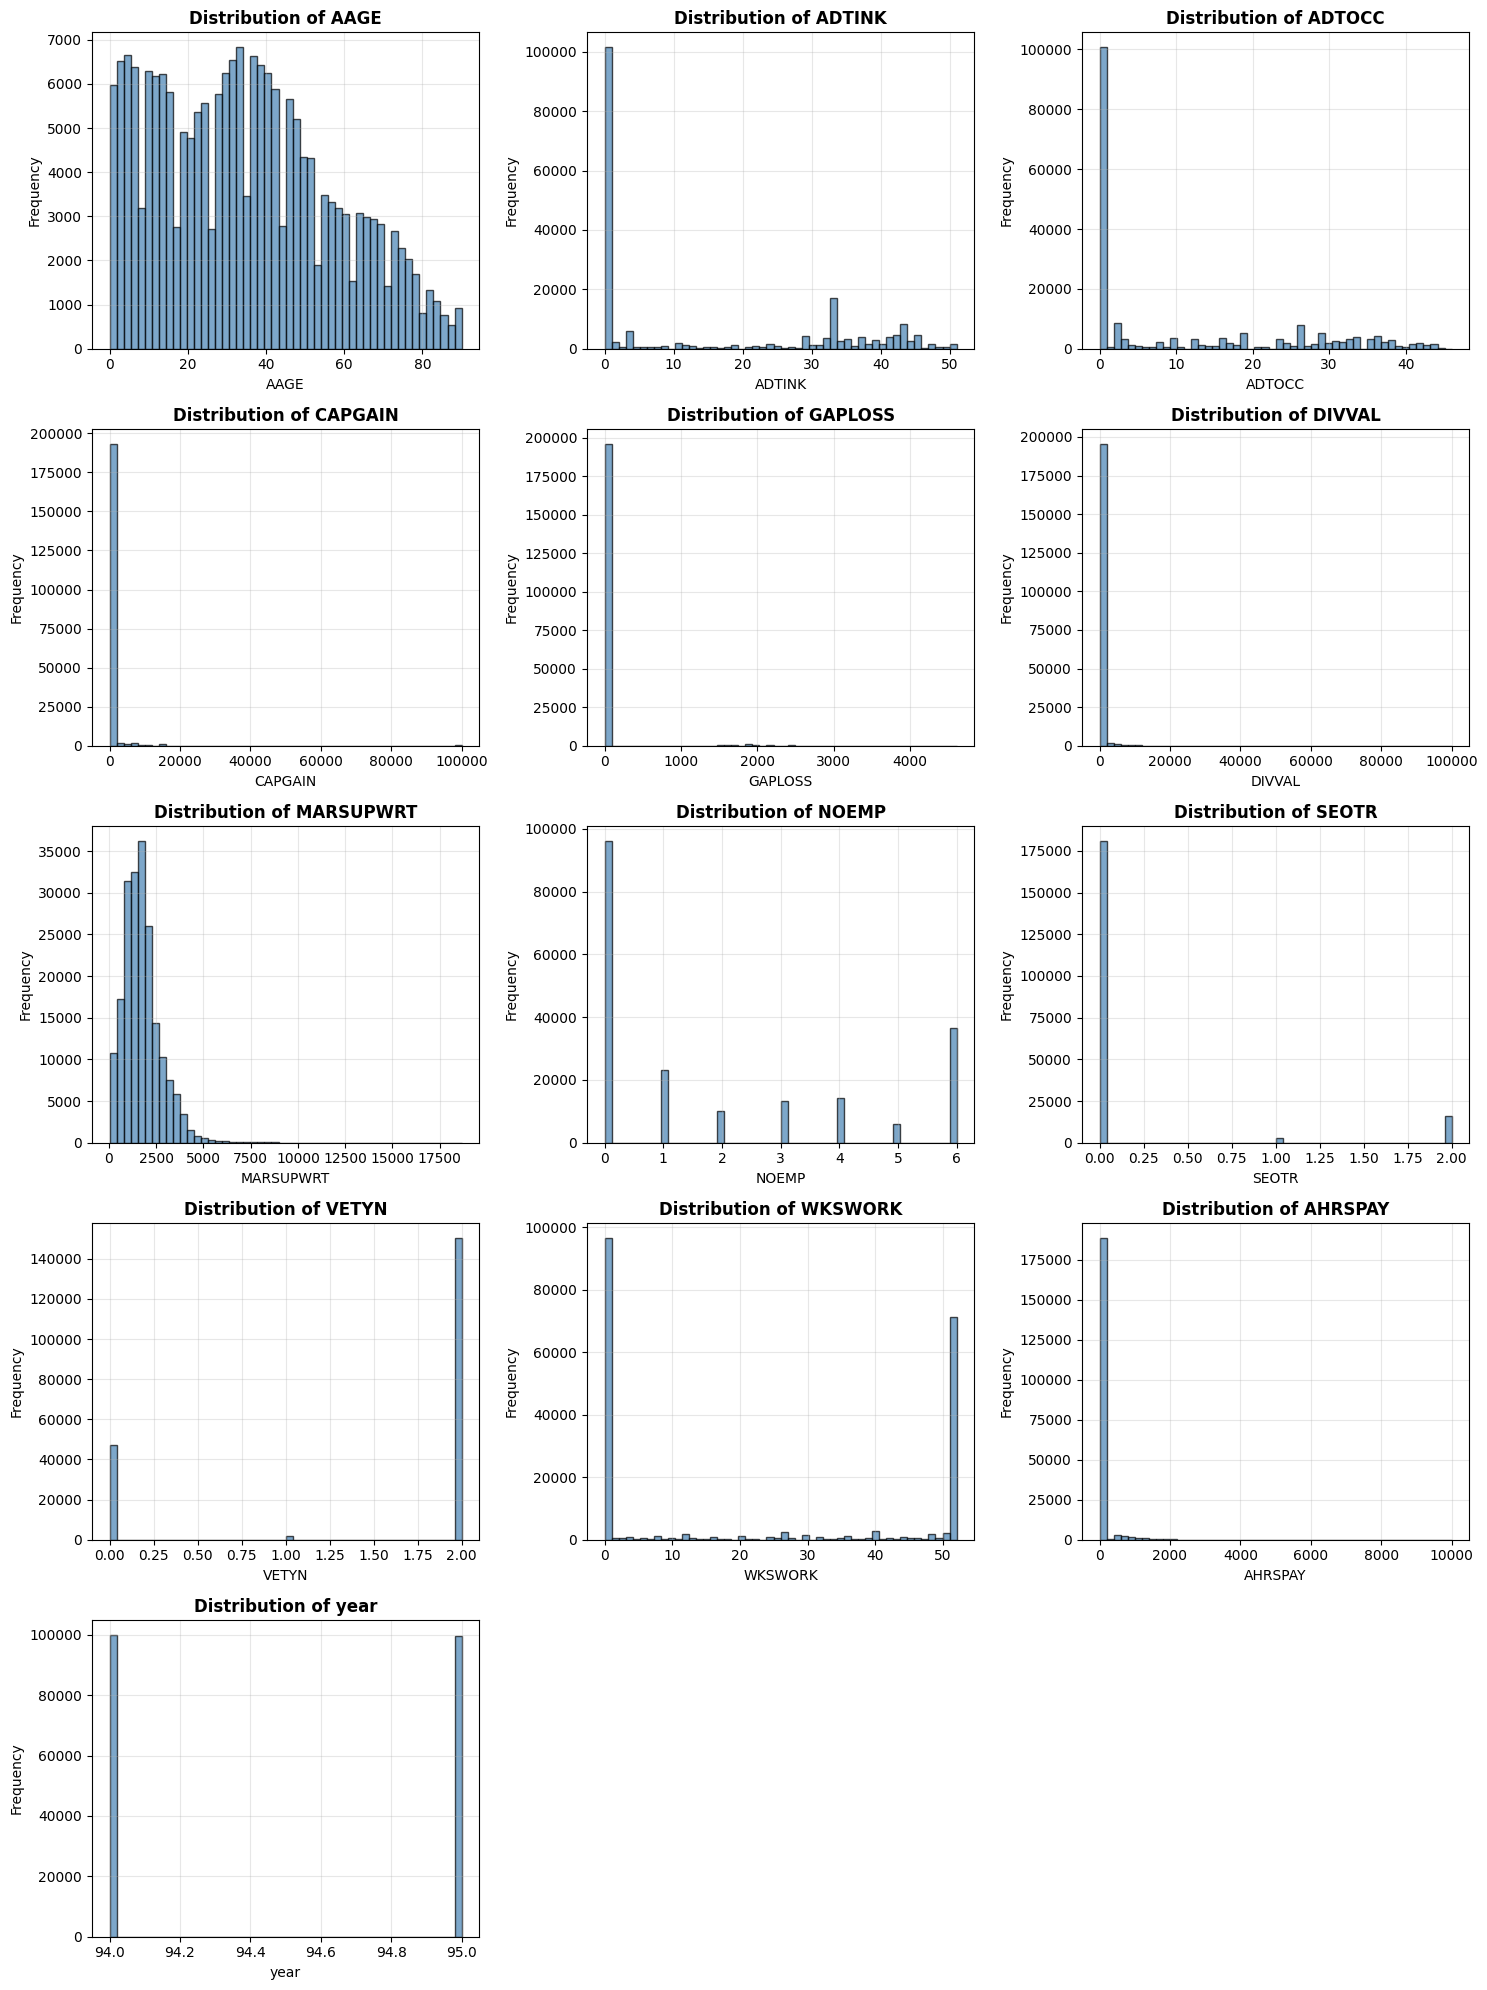

In [ ]:
# Visualize numerical distributions
n_numerical = len(numerical_cols)
n_cols = 3
n_rows = (n_numerical + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
if n_numerical == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(data[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Hiding extra subplots
for idx in range(n_numerical, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Categorical variables overview
print("="*50)
print("CATEGORICAL VARIABLES - UNIQUE VALUES")
print("="*50)

for col in categorical_cols:
    n_unique = data[col].nunique()
    print(f"\n{col}:")
    print(f"  Unique values: {n_unique}")
    if n_unique <= 20:
        print(f"  Value counts:")
        print(data[col].value_counts().head(10).to_string())

CATEGORICAL VARIABLES - UNIQUE VALUES

ACLSWKR:
  Unique values: 9
  Value counts:
ACLSWKR
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165

AHGA:
  Unique values: 17
  Value counts:
AHGA
High school graduate                      48407
Children                                  47422
Some college but no degree                27820
Bachelors degree(BA AB BS)                19865
7th and 8th grade                          8007
10th grade                                 7557
11th grade                                 6876
Masters degree(MA MS MEng MEd MSW MBA)     6541
9th grade                                  6230
Associates degree-occup /vocational        5358

AHSCOL:
  U

In [ ]:
# Summary statistics
print("="*50)
print("NUMERICAL VARIABLES - SUMMARY STATISTICS")
print("="*50)
data[numerical_cols].describe().T

NUMERICAL VARIABLES - SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
AAGE,199523.0,34.494199,22.310895,0.00,15.000,33.00,50.00,90.0
ADTINK,199523.0,15.352320,18.067129,0.00,0.000,0.00,33.00,51.0
ADTOCC,199523.0,11.306556,14.454204,0.00,0.000,0.00,26.00,46.0
CAPGAIN,199523.0,434.718990,4697.531280,0.00,0.000,0.00,0.00,99999.0
GAPLOSS,199523.0,37.313788,271.896428,0.00,0.000,0.00,0.00,4608.0
DIVVAL,199523.0,197.529533,1984.163658,0.00,0.000,0.00,0.00,99999.0
MARSUPWRT,199523.0,1740.380269,993.768156,37.87,1061.615,1618.31,2188.61,18656.3
NOEMP,199523.0,1.956180,2.365126,0.00,0.000,1.00,4.00,6.0
SEOTR,199523.0,0.175438,0.553694,0.00,0.000,0.00,0.00,2.0
VETYN,199523.0,1.514833,0.851473,0.00,2.000,2.00,2.00,2.0


Income Analysis

TARGET VARIABLE: INCOME

Income value counts:
income
-50000      187141
 50000+.     12382
Name: count, dtype: int64

Income proportions:
income
-50000      93.79%
 50000+.     6.21%
Name: proportion, dtype: object


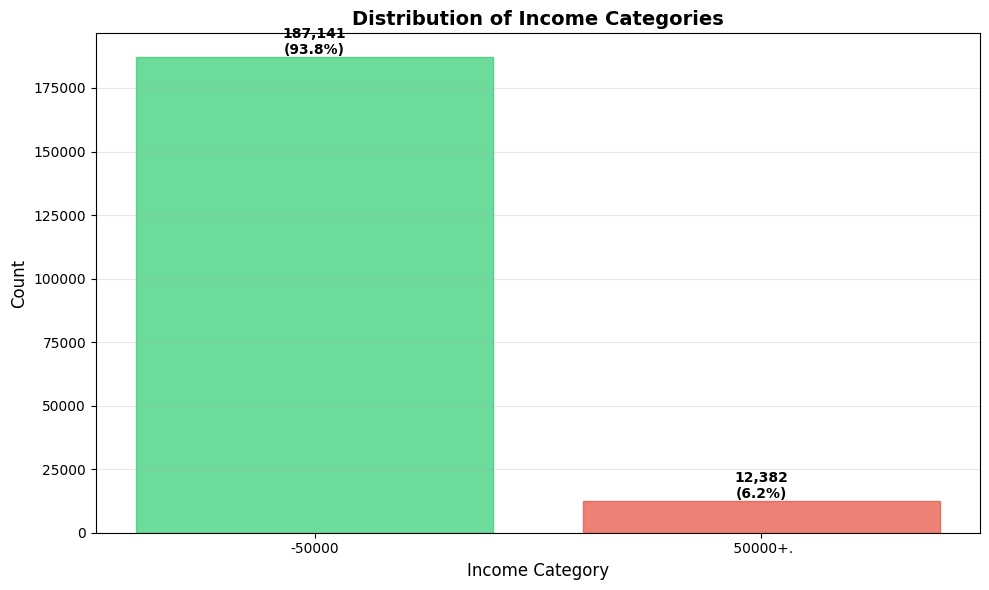

In [ ]:
# Income distribution
print("="*50)
print("TARGET VARIABLE: INCOME")
print("="*50)

print("\nIncome value counts:")
print(data['income'].value_counts())

print("\nIncome proportions:")
print(data['income'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

# Visualize
plt.figure(figsize=(10, 6))
income_counts = data['income'].value_counts()
bars = plt.bar(income_counts.index, income_counts.values, edgecolor='black', alpha=0.7)

# Color bars differently
colors = ['#2ecc71', '#e74c3c']
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel('Income Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Income Categories', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (index, value) in enumerate(income_counts.items()):
    plt.text(i, value, f'{value:,}\n({value/len(data)*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Income Relationships

Checking for age-related columns...
Age columns found: ['AAGE']


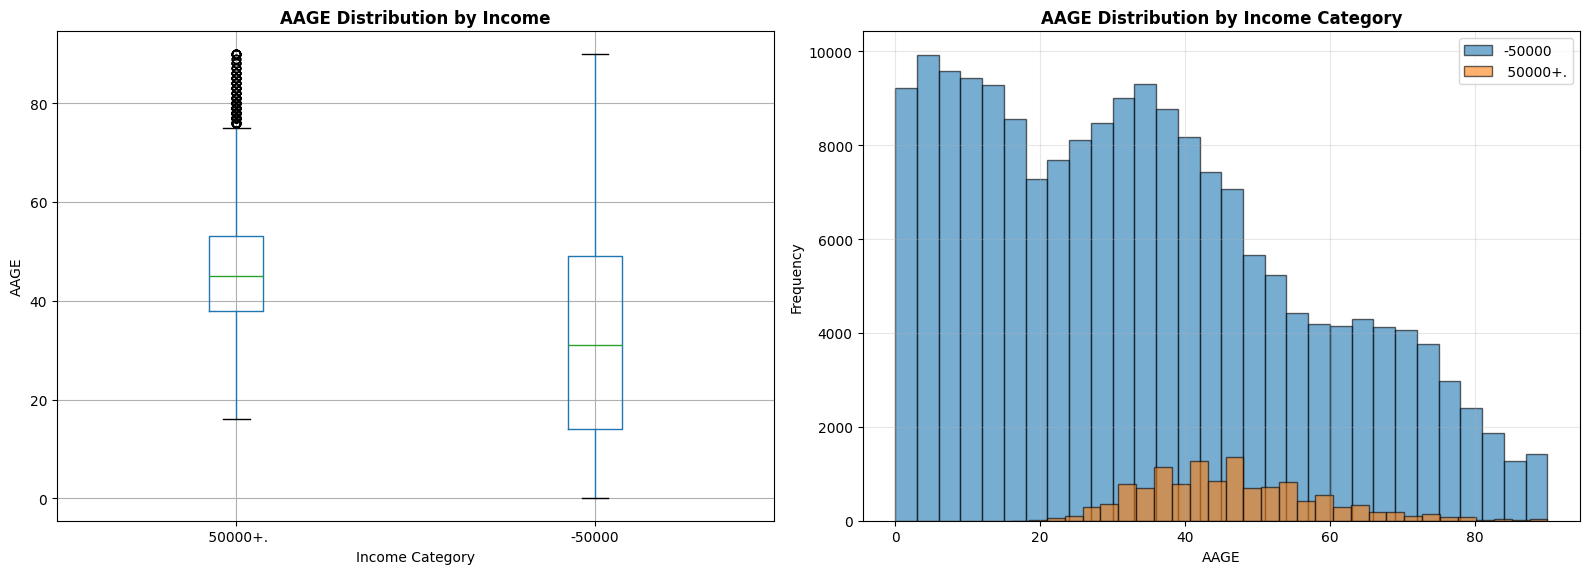

In [ ]:
# Income by Age (if age column exists)
print("Checking for age-related columns...")
age_cols = [col for col in data.columns if 'age' in col.lower()]
print(f"Age columns found: {age_cols}")

if len(age_cols) > 0:
    age_col = age_cols[0]  # age
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Box plot
    data.boxplot(column=age_col, by='income', ax=axes[0])
    axes[0].set_title(f'{age_col} Distribution by Income', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Income Category')
    axes[0].set_ylabel(age_col)
    plt.suptitle('')  # Remove default title
    
    # Histogram
    for income_cat in data['income'].unique():
        subset = data[data['income'] == income_cat][age_col]
        axes[1].hist(subset, bins=30, alpha=0.6, label=income_cat, edgecolor='black')
    
    axes[1].set_xlabel(age_col)
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{age_col} Distribution by Income Category', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Income by Education (if education column exists)
print("Checking for education-related columns...")
edu_cols = [col for col in data.columns if 'edu' in col.lower()]
print(f"Education columns found: {edu_cols}")

if len(edu_cols) > 0:
    edu_col = edu_cols[0]
    
    # Crosstab
    edu_income_ct = pd.crosstab(data[edu_col], data['income'], normalize='index') * 100
    
    edu_income_ct.plot(kind='barh', figsize=(12, 8), edgecolor='black', stacked=False)
    plt.title(f'Income Distribution by {edu_col} (%)', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage', fontsize=12)
    plt.ylabel(edu_col, fontsize=12)
    plt.legend(title='Income', bbox_to_anchor=(1.05, 1))
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\nCrosstab (counts):")
    print(pd.crosstab(data[edu_col], data['income']))

Checking for education-related columns...
Education columns found: []


In [ ]:
# EDA Summary
print("="*70)
print("EXPLORATORY DATA ANALYSIS - INITIAL SUMMARY")
print("="*70)

print(f"\nDATASET OVERVIEW:")
print(f"   • Total records: {len(data):,}")
print(f"   • Total features: {data.shape[1] - 1}")  # -1 for target
print(f"   • Numerical features: {len(numerical_cols)}")
print(f"   • Categorical features: {len(categorical_cols)}")

print(f"\nTARGET VARIABLE (Income):")
for category, count in data['income'].value_counts().items():
    pct = (count / len(data)) * 100
    print(f"   • {category}: {count:,} ({pct:.1f}%)")

print(f"\nDATA QUALITY:")
total_missing = data.isnull().sum().sum()
if total_missing > 0:
    print(f"   • Total missing values: {total_missing:,}")
    print(f"   • Columns with missing data: {(data.isnull().sum() > 0).sum()}")
else:
    print(f"   • ✓ No missing values")

print(f"   • Duplicate rows: {duplicates:,} ({duplicates/len(data)*100:.2f}%)")

print("\n" + "="*70)

EXPLORATORY DATA ANALYSIS - INITIAL SUMMARY

DATASET OVERVIEW:
   • Total records: 199,523
   • Total features: 41
   • Numerical features: 13
   • Categorical features: 28

TARGET VARIABLE (Income):
   • -50000: 187,141 (93.8%)
   •  50000+.: 12,382 (6.2%)

DATA QUALITY:
   • Total missing values: 415,717
   • Columns with missing data: 8
   • Duplicate rows: 3,229 (1.62%)



---

## Summary of All Analysis

### 1. Dataset Overview
- **Source:** UCI Census-Income (KDD) Dataset (ID: 117) — weighted census data from 1994 and 1995 Current Population Surveys (U.S. Census Bureau).
- **Size:** 199,523 records × 42 columns (41 features + 1 target).
- **Task:** Binary classification (income below or above $50K).
- **Target:** `income` — values `-50000` (below $50K) and `50000+` (above $50K).

### 2. Data Structure & Variable Types
- **Numerical (13):** AAGE, ADTINK, ADTOCC, CAPGAIN, GAPLOSS, DIVVAL, MARSUPWRT, NOEMP, SEOTR, VETYN, WKSWORK, AHRSPAY, year.
- **Categorical (28):** Demographics and employment (e.g., ACLSWKR, AHGA, AMARITL, AMJIND, AMJOCC, ARACE, ASEX, PRCITSHP, migration and nationality fields).
- **Target:** `income` (binary, object type).

### 3. Basic Inspection
- First rows and `info()` show mix of integers, floats, and objects; memory ~64 MB.
- Features cover age, class of worker, industry/occupation, education, marital status, race, sex, migration, citizenship, employment, and financial fields (capital gains/losses, dividends, etc.).

### 4. Data Quality
- **Missing values:** 8 columns have missing data:
  - **High (~50%):** MIGMTR1, MIGMTR3, MIGMTR4, MIGSUN (migration-related).
  - **Low–moderate:** PEFNTVTY (~3.4%), PEMNTVTY (~3.1%), PENATVTY (~1.7%), GRINST (~0.35%).
- **Duplicates:** Checked for duplicate rows; proportion reported in the EDA summary.
- Implications: Migration and some nationality columns need a missingness strategy (imputation, drop, or “unknown” category) before modeling.

### 5. Inconsistencies in Data
- **Duplicate rows:** 3,229 fully duplicate rows (1.62% of records) — same feature values repeated; may need deduplication or investigation to avoid overcounting in modeling.
- **Target encoding:** The `income` variable is stored as strings with values `-50000` and ` 50000+.` (note the leading space and trailing period in the high-income label). This formatting inconsistency should be standardized (e.g., strip whitespace, normalize to "<=50K" / ">50K" or 0/1) before modeling.
- **Mixed data types:** Some columns that are conceptually categorical or ordinal are stored as different dtypes (e.g., integer vs object) across similar fields (e.g., AWKSTAT, MIGSAME as object; VETYN as int64), which can cause inconsistent behavior in pipelines unless explicitly handled.
- **Sentinel / catch-all values:** Many categorical columns use **"Not in universe"** as a catch-all. This can mask true missingness or represent "question does not apply" — it is not the same as NaN but can be inconsistent across columns in meaning.
- **Column naming:** One column appears as **GAPLOSS** in the data (likely a typo for CAPLOSS — capital losses) per UCI documentation; keep this in mind when interpreting or mapping variables.
- **Recommendation:** Standardize the target labels, consider dropping or flagging duplicate rows, unify dtypes where appropriate, and document how "Not in universe" is treated (e.g., as a separate category or as missing) for modeling.

### 6. Numerical Analysis
- Summary statistics (e.g., `describe()`) for all 13 numerical variables.
- Distribution plots for numerical features to assess skewness, outliers, and scales.
- Useful for feature scaling, outlier handling, and understanding relationships with income.

### 7. Categorical Analysis
- Overview of categorical variables: value counts and cardinality.
- Highlights which categories are dominant (e.g., “Not in universe”) and which may need grouping or encoding for modeling.

### 8. Target (Income) Analysis
- **Class imbalance:** Majority class `-50000` (~93.79%), minority `50000+` (~6.21%).
- Income distribution visualized (e.g., bar chart).
- **Takeaway:** Strong imbalance — consider stratified sampling, class weights, or resampling when building classifiers.

### 9. Income Relationships
- **Income vs. Age (AAGE):** Distribution or rates of high income by age; typically higher income in middle age.
- **Income vs. Education (AHGA):** Higher education levels associated with higher share of `50000+`.
- These support that age and education are important predictors for the recommendation/classification task.

### 10. Key Takeaways for Next Steps
- **Modeling:** Binary classification with class imbalance; use metrics like precision, recall, F1, and AUC in addition to accuracy.
- **Preprocessing:** Handle missing values (especially migration and nationality); encode categoricals (e.g., one-hot or target encoding); scale numericals if using distance-based or gradient-based models.
- **Features:** Age, education, occupation/industry, weeks worked, and employment status are strong candidates; instance weight (MARSUPWRT) should not be used as a classifier feature per dataset documentation.
- **Goal:** This EDA supports building a **personalized financial recommendation system** by identifying demographic and employment factors associated with income level.